# Giveaway Above Expected Model

This notebook builds the core model of our puck management framework — 
giveaway above expected. For each 5on5 giveaway in the 2025-26 season 
we calculate how much danger it caused relative to what was expected 
given the context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)


In [2]:
# Load data
events = pd.read_csv('../data/processed/events.csv')
events = events.sort_values(['game_date', 'game_id', 'sort_order']).reset_index(drop=True)

# Compute game_seconds once, up front, so every subset inherits it
minutes = events['time_in_period'].str.split(':').str[0].astype(int)
seconds = events['time_in_period'].str.split(':').str[1].astype(int)
events['game_seconds'] = (events['period'] - 1) * 1200 + minutes * 60 + seconds

# Filter giveaways to 5on5
giveaways = events[events['event_type'] == 'giveaway']
giveaways = giveaways[giveaways['situation_code'] == 1551].copy()

print(f"Total events: {len(events)}")
print(f"5on5 giveaways: {len(giveaways)}")

Total events: 413859
5on5 giveaways: 35422


In [3]:
events.head()

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds
0,2025020001,20252026,2025-10-07,FLA,CHI,3,2,52,period-start,8,1,REG,00:00,20:00,1551,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2025020001,20252026,2025-10-07,FLA,CHI,3,2,51,faceoff,11,1,REG,00:00,20:00,1551,right,0.0,0.0,N,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2025020001,20252026,2025-10-07,FLA,CHI,3,2,101,blocked-shot,12,1,REG,00:22,19:38,1551,right,-61.0,3.0,D,NaN,13.0,NaN,NaN,8473419.0,NaN,NaN,NaN,NaN,NaN,NaN,22
3,2025020001,20252026,2025-10-07,FLA,CHI,3,2,8,stoppage,13,1,REG,00:34,19:26,1551,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34
4,2025020001,20252026,2025-10-07,FLA,CHI,3,2,55,faceoff,16,1,REG,00:34,19:26,1551,right,-69.0,22.0,D,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34


In [4]:
giveaways.head()

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds
5,2025020001,20252026,2025-10-07,FLA,CHI,3,2,74,giveaway,18,1,REG,00:46,19:14,1551,right,-41.0,38.0,O,8482113.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Anton Lundell,C,13.0,46
6,2025020001,20252026,2025-10-07,FLA,CHI,3,2,851,giveaway,24,1,REG,01:10,18:50,1551,right,-13.0,-31.0,N,8484783.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Artyom Levshunov,D,16.0,70
29,2025020001,20252026,2025-10-07,FLA,CHI,3,2,171,giveaway,66,1,REG,03:16,16:44,1551,right,14.0,-12.0,N,8473507.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Jeff Petry,D,13.0,196
61,2025020001,20252026,2025-10-07,FLA,CHI,3,2,883,giveaway,159,1,REG,09:19,10:41,1551,right,-70.0,-40.0,D,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,559
94,2025020001,20252026,2025-10-07,FLA,CHI,3,2,390,giveaway,230,1,REG,14:22,05:38,1551,right,5.0,6.0,N,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,862


In [5]:
print(events[['time_in_period', 'period', 'game_seconds']].head(10))
print(giveaways[['time_in_period', 'period', 'game_seconds']].head(10))

  time_in_period  period  game_seconds
0          00:00       1             0
1          00:00       1             0
2          00:22       1            22
3          00:34       1            34
4          00:34       1            34
5          00:46       1            46
6          01:10       1            70
7          01:13       1            73
8          01:15       1            75
9          01:15       1            75
    time_in_period  period  game_seconds
5            00:46       1            46
6            01:10       1            70
29           03:16       1           196
61           09:19       1           559
94           14:22       1           862
97           14:36       1           876
117          18:02       1          1082
118          18:07       1          1087
120          18:37       1          1117
123          19:12       1          1152


## Step 1 — Build Shot Danger Model

To calculate xGoal for each shot we first need to calculate distance 
and angle to the net for every shot in our dataset. We can then train a 
logistic regression on all shots to predict goal probability.

In [6]:
shots = events[
    (events['event_type'].isin(['shot-on-goal', 'missed-shot', 'blocked-shot', 'goal'])) &
    (events['situation_code'] == 1551)
].copy()

print(f"Total shots: {len(shots)}")
shots[['event_type', 'x_coord', 'y_coord', 'zone_code']].head(10)



Total shots: 121073


,event_type,x_coord,y_coord,zone_code
2,blocked-shot,-61.0,3.0,D
7,blocked-shot,-64.0,-16.0,D
10,shot-on-goal,-58.0,-22.0,O
15,shot-on-goal,-33.0,-19.0,O
18,missed-shot,55.0,-29.0,O
21,shot-on-goal,35.0,33.0,O
22,blocked-shot,43.0,-32.0,D
27,shot-on-goal,30.0,-34.0,O
30,blocked-shot,-56.0,-22.0,D
31,shot-on-goal,-58.0,28.0,O


In [7]:
counts = shots.groupby('event_type').size()


In [8]:
def calculate_distance_angle(x, y):
    """Calculate distance and angle to nearest net"""
    
    # Distance to both nets
    dist_right = np.sqrt((x - 89)**2 + y**2)
    dist_left = np.sqrt((x + 89)**2 + y**2)
    
    # Take the closer net
    if dist_right < dist_left:
        net_x = 89
    else:
        net_x = -89
    
    distance = min(dist_right, dist_left)
    angle = np.degrees(np.arctan2(abs(y), abs(abs(net_x) - abs(x))))
    
    return distance, angle

# Apply to all shots
shots['distance'] = shots.apply(
    lambda row: calculate_distance_angle(row['x_coord'], row['y_coord'])[0] 
    if pd.notna(row['x_coord']) else None, axis=1
)

shots['angle'] = shots.apply(
    lambda row: calculate_distance_angle(row['x_coord'], row['y_coord'])[1] 
    if pd.notna(row['x_coord']) else None, axis=1
)

shots[['event_type', 'x_coord', 'y_coord', 'distance', 'angle']].head(10)

,event_type,x_coord,y_coord,distance,angle
2,blocked-shot,-61.0,3.0,28.160256,6.115504
7,blocked-shot,-64.0,-16.0,29.681644,32.619243
10,shot-on-goal,-58.0,-22.0,38.013156,35.362462
15,shot-on-goal,-33.0,-19.0,59.135438,18.741340
18,missed-shot,55.0,-29.0,44.687806,40.462227
21,shot-on-goal,35.0,33.0,63.285069,31.429566
22,blocked-shot,43.0,-32.0,56.035703,34.824489
27,shot-on-goal,30.0,-34.0,68.095521,29.953608
30,blocked-shot,-56.0,-22.0,39.661064,33.690068
31,shot-on-goal,-58.0,28.0,41.773197,42.089162


For each shot (blocked shots, SOG's, missed shots, goals) we now have the distange and angle in relation to the net!

In [9]:
shots.head()

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,distance,angle
2,2025020001,20252026,2025-10-07,FLA,CHI,3,2,101,blocked-shot,12,1,REG,00:22,19:38,1551,right,-61.0,3.0,D,NaN,13.0,NaN,NaN,8473419.0,NaN,NaN,NaN,NaN,NaN,NaN,22,28.160256,6.115504
7,2025020001,20252026,2025-10-07,FLA,CHI,3,2,67,blocked-shot,25,1,REG,01:13,18:47,1551,right,-64.0,-16.0,D,NaN,13.0,NaN,NaN,8482713.0,NaN,NaN,NaN,NaN,NaN,NaN,73,29.681644,32.619243
10,2025020001,20252026,2025-10-07,FLA,CHI,3,2,71,shot-on-goal,29,1,REG,01:16,18:44,1551,right,-58.0,-22.0,O,NaN,13.0,NaN,NaN,8478542.0,NaN,NaN,NaN,NaN,NaN,NaN,76,38.013156,35.362462
15,2025020001,20252026,2025-10-07,FLA,CHI,3,2,102,shot-on-goal,35,1,REG,01:35,18:25,1551,right,-33.0,-19.0,O,NaN,13.0,NaN,NaN,8478055.0,NaN,NaN,NaN,NaN,NaN,NaN,95,59.135438,18.741340
18,2025020001,20252026,2025-10-07,FLA,CHI,3,2,80,missed-shot,38,1,REG,01:44,18:16,1551,right,55.0,-29.0,O,NaN,16.0,NaN,NaN,8484144.0,NaN,NaN,NaN,NaN,NaN,NaN,104,44.687806,40.462227


In [10]:
shots['is_goal'] = (shots['event_type'] == 'goal').astype(int)

print(f"Total shots: {len(shots)}")
print(f"Total goals: {shots['is_goal'].sum()}")

# Drop rows with missing distance or angle
shots_clean = shots.dropna(subset=['distance', 'angle']).copy()

#can use whether or not a shot was or target as a feature along with distance and angle
shots_clean['is_on_target'] = (shots_clean['event_type'].isin(['shot-on-goal', 'goal'])).astype(int)

# Features and target 
shots_fenwick = shots_clean[shots_clean['event_type'] != 'blocked-shot'].copy()
X = shots_fenwick[['distance', 'angle']]
y = shots_fenwick['is_goal']

print(f"Training on {len(shots_fenwick)} shots")
print(f"Features: distance, angle")
print(f"Target: is_goal")

shots_fenwick.head(5)



Total shots: 121073
Total goals: 5362
Training on 87452 shots
Features: distance, angle
Target: is_goal


,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,distance,angle,is_goal,is_on_target
10,2025020001,20252026,2025-10-07,FLA,CHI,3,2,71,shot-on-goal,29,1,REG,01:16,18:44,1551,right,-58.0,-22.0,O,NaN,13.0,NaN,NaN,8478542.0,NaN,NaN,NaN,NaN,NaN,NaN,76,38.013156,35.362462,0,1
15,2025020001,20252026,2025-10-07,FLA,CHI,3,2,102,shot-on-goal,35,1,REG,01:35,18:25,1551,right,-33.0,-19.0,O,NaN,13.0,NaN,NaN,8478055.0,NaN,NaN,NaN,NaN,NaN,NaN,95,59.135438,18.741340,0,1
18,2025020001,20252026,2025-10-07,FLA,CHI,3,2,80,missed-shot,38,1,REG,01:44,18:16,1551,right,55.0,-29.0,O,NaN,16.0,NaN,NaN,8484144.0,NaN,NaN,NaN,NaN,NaN,NaN,104,44.687806,40.462227,0,0
21,2025020001,20252026,2025-10-07,FLA,CHI,3,2,86,shot-on-goal,43,1,REG,02:02,17:58,1551,right,35.0,33.0,O,NaN,16.0,NaN,NaN,8482807.0,NaN,NaN,NaN,NaN,NaN,NaN,122,63.285069,31.429566,0,1
27,2025020001,20252026,2025-10-07,FLA,CHI,3,2,153,shot-on-goal,61,1,REG,02:52,17:08,1551,right,30.0,-34.0,O,NaN,16.0,NaN,NaN,8483506.0,NaN,NaN,NaN,NaN,NaN,NaN,172,68.095521,29.953608,0,1


In [11]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.19048522,  0.0876871 ],
       [ 1.23738801, -0.69631408],
       [ 0.52130696,  0.32823779],
       ...,
       [ 1.82648901, -0.05452821],
       [ 0.28151241,  1.8382205 ],
       [-0.05798635, -1.58032381]], shape=(87452, 2))

We can see that the output above shows the scaled version of our two features (distance and angle)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.coef_[0])        # array of [w_distance, w_angle]

[-0.90737791 -0.31920085]


### Model 1 coefficient interpretation

Fitted logistic regression weights (on standardized features):

| Feature | Coefficient | Sign check |
|---|---|---|
| `distance` | −0.907 | ✅ negative — farther from net lowers scoring probability |
| `angle` | −0.319 | ✅ negative — wider angle lowers scoring probability |

**Key observations:**

- `distance` outweighs `angle` by about 3.2x. Proximity to the net is a stronger predictor here than shot angle, though both contribute meaningfully.




In [13]:
# Evaluate on test set
train_auc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
test_auc = cross_val_score(model, X_test, y_test, cv=5, scoring='roc_auc').mean()

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")
print(f"Difference: {abs(train_auc - test_auc):.3f}")



Train AUC: 0.729
Test AUC:  0.730
Difference: 0.002


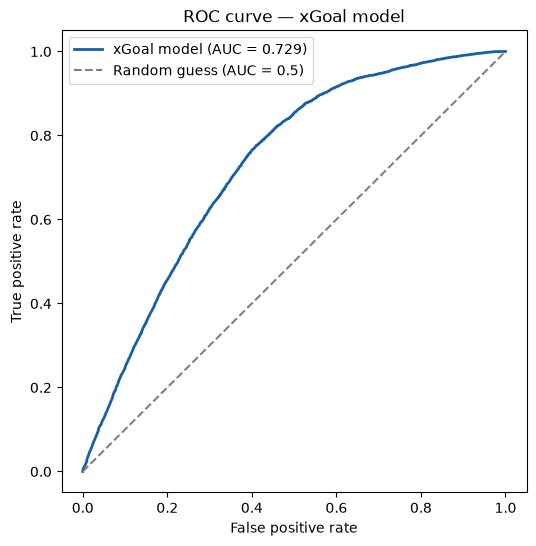

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X_all_scaled = scaler.transform(shots_fenwick[['distance', 'angle']])
probs = model.predict_proba(X_all_scaled)[:, 1]
y_true = shots_fenwick['is_goal']

fpr, tpr, thresholds = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='#185FA5', linewidth=2, label=f'xGoal model (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — xGoal model')
plt.legend()
plt.show()

In [15]:
# Generate xGoal for every shot, apply our model to our whole shots dataset!
X_all = shots_clean[['distance', 'angle']]
X_all_scaled = scaler.transform(X_all)

# Generate xGoal for all shots
shots_clean['xGoal'] = model.predict_proba(X_all_scaled)[:, 1]
print(shots_clean[['event_type', 'distance', 'angle', 'xGoal']].head(10))
print(shots_clean['xGoal'].describe())

      event_type   distance      angle     xGoal
2   blocked-shot  28.160256   6.115504  0.085270
7   blocked-shot  29.681644  32.619243  0.055186
10  shot-on-goal  38.013156  35.362462  0.037102
15  shot-on-goal  59.135438  18.741340  0.018781
18   missed-shot  44.687806  40.462227  0.025750
21  shot-on-goal  63.285069  31.429566  0.012950
22  blocked-shot  56.035703  34.824489  0.016978
27  shot-on-goal  68.095521  29.953608  0.010690
30  blocked-shot  39.661064  33.690068  0.035393
31  shot-on-goal  41.773197  42.089162  0.028563
count    121073.000000
mean          0.065994
std           0.048024
min           0.003038
25%           0.027159
50%           0.052132
75%           0.094410
max           0.266144
Name: xGoal, dtype: float64


### The lowest-xG goal in the dataset

Every model gets some outcomes "wrong" in the sense that reality doesn't match the odds — that's expected, not a flaw. Here's the most extreme case in the dataset: a goal from a location the model considered almost hopeless.

In [16]:
lowest_goal = shots_clean[shots_clean['event_type']=='goal'].sort_values('xGoal').head(1)
print(lowest_goal[['game_id', 'game_date' ,'period', 'time_remaining', 'xGoal']])

           game_id   game_date  period time_remaining     xGoal
257870  2025020814  2026-01-24       1          12:12  0.006243


This is the single lowest-probability shot in the entire 2025-26 season that still ended up in the net. Jake Guentzel released a shot from just inside his own half of the ice — the model's two features (distance, angle) correctly flagged this as an extreme long shot with almost no realistic chance of scoring, well below the season-wide median xGoal of 0.052.

What actually happened: the goalie made the initial save cleanly, played the puck out of the crease, and it deflected off a defenseman's skate and crossed the goal line!

In [17]:
shots_clean.loc[shots_clean['xGoal'].idxmax()]

game_id                       2025020065
season                          20252026
game_date                     2025-10-16
home_team                            NYI
away_team                            EDM
home_score_final                       4
away_score_final                       2
event_id                             302
event_type                  blocked-shot
sort_order                           161
period                                 1
period_type                          REG
time_in_period                     12:11
time_remaining                     07:49
situation_code                      1551
home_team_defending_side            left
x_coord                            -89.0
y_coord                              0.0
zone_code                              D
player_id                            NaN
event_owner_team_id                 22.0
hitting_player_id                    NaN
hittee_player_id                     NaN
shooting_player_id             8477953.0
scoring_player_i

In [18]:
highest_goals = shots_clean[shots_clean['event_type'] == 'goal']
highest_goals.loc[highest_goals['xGoal'].idxmax()]

game_id                     2025020718
season                        20252026
game_date                   2026-01-12
home_team                          NYR
away_team                          SEA
home_score_final                     2
away_score_final                     4
event_id                           893
event_type                        goal
sort_order                         670
period                               3
period_type                        REG
time_in_period                   12:02
time_remaining                   07:58
situation_code                    1551
home_team_defending_side         right
x_coord                           88.0
y_coord                            0.0
zone_code                            O
player_id                          NaN
event_owner_team_id               55.0
hitting_player_id                  NaN
hittee_player_id                   NaN
shooting_player_id                 NaN
scoring_player_id            8484800.0
away_score               

This is the highest xGoal shot in the wholte dataset! We can see hes pretty much on the goal line directly in front of the net (angle of 0) so someone basically tapped it in from right on the goal line, straight on. Our model correctly identified it as the highest danger goal.

## xGoal Model

To measure the danger caused by each giveaway we built a simple xGoal model 
that predicts the probability of a shot becoming a goal based on shot context.

### Model Details
- **Algorithm:** Logistic Regression
- **Training data:** 87452 Fenwick shot attempts from the 2025-26 NHL regular season
- **Validation:** 5-fold cross validation

### Features
| Feature | Description |
|---|---|
| `distance` | Distance to nearest net calculated from x/y coordinates using Pythagoras |
| `angle` | Angle to net calculated using arctan |

### Performance
- **AUC: 0.729** — strong performance, comparable to professional xGoal models



## Step 3 — Label Each Giveaway with Actual Danger Score

For each of our 35,422 5on5 giveaways we need to measure how much 
danger it actually caused. We do this by looking at what happened 
immediately after each giveaway.

**The process for each giveaway:**
1. Record the exact game second it occurred
2. Look at all events in the same game within the next 10 seconds
3. Filter to shots only (shot-on-goal, missed-shot, blocked-shot, goal)
4. Filter to shots by the OPPOSING team only — we don't want to count 
   shots by the same team that gave the puck away
5. If a shot is found → assign its xGoal value as the danger score
6. If no shot is found within 10 seconds → danger score = 0

**Why 10 seconds?**
A shot within 10 seconds of a giveaway is very likely directly caused 
by that turnover. Beyond 10 seconds play has likely reset and the 
connection between the giveaway and any subsequent shot becomes 
increasingly weak.

In [19]:
giveaways.columns

Index(['game_id', 'season', 'game_date', 'home_team', 'away_team',
       'home_score_final', 'away_score_final', 'event_id', 'event_type',
       'sort_order', 'period', 'period_type', 'time_in_period',
       'time_remaining', 'situation_code', 'home_team_defending_side',
       'x_coord', 'y_coord', 'zone_code', 'player_id', 'event_owner_team_id',
       'hitting_player_id', 'hittee_player_id', 'shooting_player_id',
       'scoring_player_id', 'away_score', 'home_score', 'player_name',
       'position_code', 'player_team_id', 'game_seconds'],
      dtype='str')

In [20]:
stoppage_events = events[events['event_type'] == 'stoppage']
shots_and_stoppages = pd.concat([shots_clean, stoppage_events], ignore_index=True)
shots_and_stoppages = shots_and_stoppages.sort_values(['game_id', 'sort_order']).reset_index(drop=True)
print(shots_and_stoppages['event_type'].value_counts())

shots_and_stoppages.head(5)

event_type
stoppage        57202
shot-on-goal    51066
blocked-shot    33621
missed-shot     31024
goal             5362
Name: count, dtype: int64


,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,distance,angle,is_goal,is_on_target,xGoal
0,2025020001,20252026,2025-10-07,FLA,CHI,3,2,101,blocked-shot,12,1,REG,00:22,19:38,1551,right,-61.0,3.0,D,NaN,13.0,NaN,NaN,8473419.0,NaN,NaN,NaN,NaN,NaN,NaN,22,28.160256,6.115504,0.0,0.0,0.085270
1,2025020001,20252026,2025-10-07,FLA,CHI,3,2,8,stoppage,13,1,REG,00:34,19:26,1551,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,NaN,NaN,NaN,NaN,NaN
2,2025020001,20252026,2025-10-07,FLA,CHI,3,2,67,blocked-shot,25,1,REG,01:13,18:47,1551,right,-64.0,-16.0,D,NaN,13.0,NaN,NaN,8482713.0,NaN,NaN,NaN,NaN,NaN,NaN,73,29.681644,32.619243,0.0,0.0,0.055186
3,2025020001,20252026,2025-10-07,FLA,CHI,3,2,9,stoppage,26,1,REG,01:15,18:45,1551,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN
4,2025020001,20252026,2025-10-07,FLA,CHI,3,2,71,shot-on-goal,29,1,REG,01:16,18:44,1551,right,-58.0,-22.0,O,NaN,13.0,NaN,NaN,8478542.0,NaN,NaN,NaN,NaN,NaN,NaN,76,38.013156,35.362462,0.0,1.0,0.037102


In [21]:
danger_scores = []
blocked_shot_counts = []

for idx, row in giveaways.iterrows():
    giveaway_second = row['game_seconds']
    
    window_events = shots_and_stoppages[
        (shots_and_stoppages['game_id'] == row['game_id']) &
        (shots_and_stoppages['game_seconds'] >= giveaway_second) &
        (shots_and_stoppages['game_seconds'] <= giveaway_second + 15)
    ]
    
    stoppages_in_window = window_events[window_events['event_type'] == 'stoppage']
    
    if len(stoppages_in_window) > 0:
        window_end = stoppages_in_window['game_seconds'].min()
    else:
        window_end = giveaway_second + 15
    
    shots_after = window_events[
        (window_events['game_seconds'] <= window_end) &
        (window_events['event_owner_team_id'] != row['event_owner_team_id']) &
        (window_events['event_type'].isin(['shot-on-goal', 'missed-shot', 'goal', 'blocked-shot']))
    ]
    
    fenwick_shots = shots_after[shots_after['event_type'] != 'blocked-shot']
    blocked_shots = shots_after[shots_after['event_type'] == 'blocked-shot']
    
    danger_scores.append(fenwick_shots['xGoal'].sum())
    blocked_shot_counts.append(len(blocked_shots))

giveaways['danger_score'] = danger_scores
giveaways['blocked_shot_count'] = blocked_shot_counts

print(f"Giveaways with danger score > 0: {(giveaways['danger_score'] > 0).sum()}")
print(f"Giveaways followed by a blocked shot: {(giveaways['blocked_shot_count'] > 0).sum()}")
print(f"Average danger score: {giveaways['danger_score'].mean():.4f}")
print(giveaways['danger_score'].describe())

Giveaways with danger score > 0: 8504
Giveaways followed by a blocked shot: 3451
Average danger score: 0.0174
count    35422.000000
mean         0.017420
std          0.045015
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.673484
Name: danger_score, dtype: float64


In [22]:
giveaways.head()

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,danger_score,blocked_shot_count
5,2025020001,20252026,2025-10-07,FLA,CHI,3,2,74,giveaway,18,1,REG,00:46,19:14,1551,right,-41.0,38.0,O,8482113.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Anton Lundell,C,13.0,46,0.000000,0
6,2025020001,20252026,2025-10-07,FLA,CHI,3,2,851,giveaway,24,1,REG,01:10,18:50,1551,right,-13.0,-31.0,N,8484783.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Artyom Levshunov,D,16.0,70,0.000000,1
29,2025020001,20252026,2025-10-07,FLA,CHI,3,2,171,giveaway,66,1,REG,03:16,16:44,1551,right,14.0,-12.0,N,8473507.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Jeff Petry,D,13.0,196,0.000000,0
61,2025020001,20252026,2025-10-07,FLA,CHI,3,2,883,giveaway,159,1,REG,09:19,10:41,1551,right,-70.0,-40.0,D,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,559,0.013762,0
94,2025020001,20252026,2025-10-07,FLA,CHI,3,2,390,giveaway,230,1,REG,14:22,05:38,1551,right,5.0,6.0,N,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,862,0.000000,0


In [23]:
print(f"Zero danger, no blocked shot at all (truly quiet): {((giveaways['danger_score']==0) & (giveaways['blocked_shot_count']==0)).sum()}")
print(f"Zero danger, but blocked shot occurred: {((giveaways['danger_score']==0) & (giveaways['blocked_shot_count']>0)).sum()}")
print(f"Nonzero danger score: {(giveaways['danger_score']>0).sum()}")

Zero danger, no blocked shot at all (truly quiet): 24331
Zero danger, but blocked shot occurred: 2587
Nonzero danger score: 8504


In [24]:
highest_danger_score = giveaways.loc[giveaways['danger_score'].idxmax()]

giveaway_second = highest_danger_score['game_seconds']

# Same window logic as the danger_score loop above (cell 30) — capped at the
# first stoppage if one occurs, so this always agrees with danger_score itself
window_events = shots_and_stoppages[
    (shots_and_stoppages['game_id'] == highest_danger_score['game_id']) &
    (shots_and_stoppages['game_seconds'] >= giveaway_second) &
    (shots_and_stoppages['game_seconds'] <= giveaway_second + 15)
]

stoppages_in_window = window_events[window_events['event_type'] == 'stoppage']
window_end = stoppages_in_window['game_seconds'].min() if len(stoppages_in_window) > 0 else giveaway_second + 15

contributing_shots = window_events[
    (window_events['game_seconds'] <= window_end) &
    (window_events['event_owner_team_id'] != highest_danger_score['event_owner_team_id']) &
    (window_events['event_type'].isin(['shot-on-goal', 'missed-shot', 'goal', 'blocked-shot']))
]

contributing_shots

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,distance,angle,is_goal,is_on_target,xGoal
11997,2025020089,20252026,2025-10-19,WSH,VAN,3,4,152,shot-on-goal,241,1,REG,17:05,02:55,1551,right,81.0,0.0,O,NaN,23.0,NaN,NaN,8480078.0,NaN,NaN,NaN,NaN,NaN,NaN,1025,8.000000,0.000000,0.0,1.0,0.201964
11998,2025020089,20252026,2025-10-19,WSH,VAN,3,4,751,shot-on-goal,242,1,REG,17:07,02:53,1551,right,82.0,-1.0,O,NaN,23.0,NaN,NaN,8481024.0,NaN,NaN,NaN,NaN,NaN,NaN,1027,7.071068,8.130102,0.0,1.0,0.189280
11999,2025020089,20252026,2025-10-19,WSH,VAN,3,4,752,shot-on-goal,243,1,REG,17:08,02:52,1551,right,81.0,0.0,O,NaN,23.0,NaN,NaN,8481024.0,NaN,NaN,NaN,NaN,NaN,NaN,1028,8.000000,0.000000,0.0,1.0,0.201964
12000,2025020089,20252026,2025-10-19,WSH,VAN,3,4,590,goal,245,1,REG,17:11,02:49,1551,right,81.0,-11.0,O,NaN,23.0,NaN,NaN,NaN,8474574.0,2.0,0.0,NaN,NaN,NaN,1031,13.601471,53.972627,1.0,1.0,0.080275


In [25]:
highest_danger_score

game_id                           2025020089
season                              20252026
game_date                         2025-10-19
home_team                                WSH
away_team                                VAN
home_score_final                           3
away_score_final                           4
event_id                                 598
event_type                          giveaway
sort_order                               240
period                                     1
period_type                              REG
time_in_period                         17:00
time_remaining                         03:00
situation_code                          1551
home_team_defending_side               right
x_coord                                 45.0
y_coord                                  2.0
zone_code                                  D
player_id                          8481580.0
event_owner_team_id                     15.0
hitting_player_id                        NaN
hittee_pla

### Most Dangerous Giveaway

As a sanity check, we identified the giveaway with the highest danger score
in the dataset — a defensive-zone giveaway in game 2025020089 (WSH @ VAN on Oct 19th), period 1,
at game second 1020.

**What happened:**
A Connor McMichael giveaway occurs at the blue line in his team's own defensive
zone — notably not an extreme location, nowhere near the crease. Three shots on
goal follow in quick succession, then a goal five seconds later, all within 11
seconds of the giveaway with no intervening stoppage:

| Shot | Time (game seconds) | Distance | Angle | xGoal |
|---|---|---|---|---|
| Shot on goal | 1025 | 8.0 ft | 0.0° | 0.202 |
| Shot on goal | 1027 | 7.1 ft | 8.1° | 0.189 |
| Shot on goal | 1028 | 8.0 ft | 0.0° | 0.202 |
| Goal | 1031 | 13.6 ft | 54.0° | 0.080 |

**Combined danger score: 0.673484**

This is a genuine defensive breakdown: three close-range shot attempts within
8 seconds of the giveaway, then a goal 3 seconds after that — no stoppage
anywhere in the sequence, so the full window counts toward the danger score.

This validates that the danger-scoring pipeline is working as intended:
the single highest danger score in the entire season corresponds to a
defensive-zone giveaway that directly led to a real, converted goal — as
unambiguous a dangerous turnover as exists in the dataset.

## Step 4 — Build the Above Expected Model (Model 2)

With every giveaway now labelled with its actual danger score, we build 
a regression model that learns what danger is expected given the context 
of each giveaway. The difference between actual and expected danger is 
our giveaway above expected metric.

In [26]:
def calculate_giveaway_distance_angle(x, y, zone_code):
    """Calculate distance and angle to the giving team's OWN net.
    
    Unlike shots (where you're always shooting at the nearest net), a giveaway's
    danger depends on distance to the net the giving team is defending — which
    is the FAR net if the giveaway happened in the offensive zone.
    """
    dist_right = np.sqrt((x - 89)**2 + y**2)
    dist_left = np.sqrt((x + 89)**2 + y**2)

    # Which net is physically nearest
    nearest_net_x = 89 if dist_right < dist_left else -89

    if zone_code == 'D':
        # Own net is the near net
        net_x = nearest_net_x
    elif zone_code == 'O':
        # Own net is the far net
        net_x = -nearest_net_x
    else:
        # Neutral zone — genuinely ambiguous, fall back to nearest as an approximation
        net_x = nearest_net_x

    distance = np.sqrt((x - net_x)**2 + y**2)
    angle = np.degrees(np.arctan2(abs(y), abs(net_x - x)))

    return distance, angle

In [27]:
print(calculate_giveaway_distance_angle(45, 2, 'D'))   # McMichael giveaway — should be a smallish distance
print(calculate_giveaway_distance_angle(-80, 0, 'O'))  # deep in the OTHER end — should be a LARGE distance now

(np.float64(44.04543109109048), np.float64(2.602562202499806))
(np.float64(169.0), np.float64(0.0))


In [28]:
da = giveaways.apply(
    lambda r: calculate_giveaway_distance_angle(r['x_coord'], r['y_coord'], r['zone_code'])
    if pd.notna(r['x_coord']) else (None, None),
    axis=1
)
giveaways['distance'] = da.apply(lambda t: t[0])
giveaways['angle'] = da.apply(lambda t: t[1])

giveaways.groupby('zone_code')['distance'].describe()

,count,mean,std,min,25%,50%,75%,max
zone_code,,,,,,,,
D,16871.0,34.283571,17.992895,3.000000,18.439089,33.241540,47.885280,76.550637
N,7281.0,83.132577,7.573733,65.000000,77.414469,83.294658,89.005618,98.412398
O,11270.0,153.239936,23.062035,114.004386,130.648383,153.287312,175.390992,189.282857


In [29]:
giveaways.groupby('zone_code')['angle'].describe()

,count,mean,std,min,25%,50%,75%,max
zone_code,,,,,,,,
D,16871.0,51.872146,24.593429,0.0,33.690068,53.569142,73.442929,90.000000
N,7281.0,19.599792,8.432004,0.0,13.706961,22.520566,25.974394,32.868679
O,11270.0,10.967215,5.106342,0.0,7.049178,11.996899,14.981633,20.224859


In [30]:
oe = OrdinalEncoder(categories=[['O', 'N', 'D']])
giveaways['zone_code_encoded'] = oe.fit_transform(giveaways[['zone_code']])

print(f"Zone encoding: O=0, N=1, D=2")
print(f"\nMissing values:\n{giveaways[['zone_code_encoded']].isnull().sum()}")
print(giveaways[['zone_code', 'zone_code_encoded']].head(10))

Zone encoding: O=0, N=1, D=2

Missing values:
zone_code_encoded    0
dtype: int64
    zone_code  zone_code_encoded
5           O                0.0
6           N                1.0
29          N                1.0
61          D                2.0
94          N                1.0
97          D                2.0
117         O                0.0
118         O                0.0
120         O                0.0
123         N                1.0


In [31]:
giveaways.head()

,game_id,season,game_date,home_team,away_team,home_score_final,away_score_final,event_id,event_type,sort_order,period,period_type,time_in_period,time_remaining,situation_code,home_team_defending_side,x_coord,y_coord,zone_code,player_id,event_owner_team_id,hitting_player_id,hittee_player_id,shooting_player_id,scoring_player_id,away_score,home_score,player_name,position_code,player_team_id,game_seconds,danger_score,blocked_shot_count,distance,angle,zone_code_encoded
5,2025020001,20252026,2025-10-07,FLA,CHI,3,2,74,giveaway,18,1,REG,00:46,19:14,1551,right,-41.0,38.0,O,8482113.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Anton Lundell,C,13.0,46,0.000000,0,135.440024,16.294047,0.0
6,2025020001,20252026,2025-10-07,FLA,CHI,3,2,851,giveaway,24,1,REG,01:10,18:50,1551,right,-13.0,-31.0,N,8484783.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Artyom Levshunov,D,16.0,70,0.000000,1,82.079230,22.190289,1.0
29,2025020001,20252026,2025-10-07,FLA,CHI,3,2,171,giveaway,66,1,REG,03:16,16:44,1551,right,14.0,-12.0,N,8473507.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,Jeff Petry,D,13.0,196,0.000000,0,75.953933,9.090277,1.0
61,2025020001,20252026,2025-10-07,FLA,CHI,3,2,883,giveaway,159,1,REG,09:19,10:41,1551,right,-70.0,-40.0,D,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,559,0.013762,0,44.283180,64.592282,2.0
94,2025020001,20252026,2025-10-07,FLA,CHI,3,2,390,giveaway,230,1,REG,14:22,05:38,1551,right,5.0,6.0,N,8483506.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,Sam Rinzel,D,16.0,862,0.000000,0,84.214013,4.085617,1.0


## Model 2, Round 1 — Distance + Angle Only

Testing whether the engineered `distance`/`angle` features (distance and angle from the giving team's own net) can explain giveaway danger on their own, before adding raw `x`/`y` coordinates and `zone_code` in Round 2. Since `distance`/`angle` are themselves calculated from `x`/`y`, starting narrow lets us see how much of the raw positional signal they actually capture — and whether the extra features in Round 2 are worth the added complexity.

Four candidates compared via 5-fold out-of-fold cross-validation:
- **Mean baseline** — predicts the overall average `danger_score` for every giveaway
- **Zone-average baseline** — predicts the average `danger_score` for that giveaway's zone (computed from the training fold only, so it's a fair out-of-fold comparison too)
- **Linear regression**
- **Random Forest**

#### Mean Baseline

In [32]:
X_r1 = giveaways[["distance", "angle"]]
y = giveaways["danger_score"]

mean_model = DummyRegressor(strategy="mean")
oof_mean_r1 = cross_val_predict(mean_model, X_r1, y, cv=5)

oof_mean_r1

array([0.01754429, 0.01754429, 0.01754429, ..., 0.01743672, 0.01743672,
       0.01743672], shape=(35422,))

Uses `DummyRegressor` to predict the overall average `danger_score` for every giveaway — the dumbest possible model, just a floor to beat.

Run via `cross_val_predict` with 5-fold CV: giveaways are split into 5 buckets, and each giveaway is predicted only by a model trained on the *other* 4 buckets — it never sees its own bucket's data. This is why the output has slightly different values across the array  rather than one single number everywhere.



#### Zone average baseline

In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_zone_r1 = np.zeros(len(giveaways))

for train_idx, test_idx in kf.split(giveaways):
    # Only look at the training rows this round — never the held-out ones
    train_zone = giveaways["zone_code"].iloc[train_idx]
    train_y = y.iloc[train_idx]

    # Same lookup table as before, but computed from training rows only
    zone_means = train_y.groupby(train_zone).mean()

    # Predict the held-out rows using that lookup table
    test_zone = giveaways["zone_code"].iloc[test_idx]
    oof_zone_r1[test_idx] = test_zone.map(zone_means).fillna(train_y.mean()).values

#### Linear Regression

In [34]:
lr = LinearRegression()
oof_linear_r1 = cross_val_predict(lr, X_r1, y, cv=5)

#### Random Forrest

In [35]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
oof_rf_r1 = cross_val_predict(rf, X_r1, y, cv=5)

#### Comparing MAE and RMSE between models

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

for name, preds in [("Mean baseline", oof_mean_r1), ("Zone baseline", oof_zone_r1),
                     ("Linear regression", oof_linear_r1), ("Random Forest", oof_rf_r1)]:
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    print(f"{name:<20} MAE: {mae:.5f}   RMSE: {rmse:.5f}")

Mean baseline        MAE: 0.02685   RMSE: 0.04502
Zone baseline        MAE: 0.02596   RMSE: 0.04448
Linear regression    MAE: 0.02595   RMSE: 0.04447
Random Forest        MAE: 0.02665   RMSE: 0.04765


In [37]:
rf_constrained = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
oof_rf_constrained = cross_val_predict(rf_constrained, X_r1, y, cv=5)

for name, preds in [("RF default (unconstrained)", oof_rf_r1), ("RF constrained (max_depth=5)", oof_rf_constrained)]:
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    print(f"{name:<30} MAE: {mae:.5f}   RMSE: {rmse:.5f}")

RF default (unconstrained)     MAE: 0.02665   RMSE: 0.04765
RF constrained (max_depth=5)   MAE: 0.02585   RMSE: 0.04442


In [38]:
rf_check = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
rf_check.fit(X_r1, y)
print(dict(zip(['distance', 'angle'], rf_check.feature_importances_)))

{'distance': np.float64(0.8964995258302274), 'angle': np.float64(0.1035004741697726)}


### Why Round 1's Random Forest Barely Uses `angle`

Checking `rf.feature_importances_` on the Round 1 model (`distance` + `angle` only) shows a clear split:

- `distance`: 90%
- `angle`: 10%

That's a real, meaningful asymmetry — not close to a 50/50 split. It explains the Q4/Q5 ranking issue from the quintile check: with `angle` barely influencing predictions, giveaways at very different angles but similar distances end up with nearly identical `expected_danger` (e.g. McMichael's giveaway at 2.6° and Matthews' at 83.7° both landed around 0.024–0.026 despite looking totally different).

This makes hockey sense once you separate the two use cases. For a **shot**, angle is the *shooter's* angle to the net — directly tied to how hard the shot is to save, which is why it mattered a lot in Model 1. For a **giveaway**, angle just describes where the puck was lost relative to the net — but the actual danger comes from whatever shot the *opponent* takes afterward, from wherever they end up, not from the giveaway's own angle. So it's reasonable that the model leaned almost entirely on `distance` and treated `angle` as a minor adjustment.

This is a genuine finding worth keeping for the writeup, not just a technical footnote: angle matters a lot for shot danger, much less for giveaway danger.

## Round 2 — Adding Raw Position and Zone

Round 1 used only `distance` and `angle`, and we found the model was leaning almost entirely on `distance` — `angle` contributed only ~10% of feature importance and didn't meaningfully separate the most dangerous giveaways from moderately dangerous ones.

Round 2 tests whether giving the model more to work with actually helps: `x_coord`, `y_coord`, and `zone_code_encoded`, in addition to `distance`/`angle`. The idea is that raw position and zone can capture spatial patterns `distance` alone can't — for example, whether a giveaway happens near the boards vs. down the middle of the ice, or systematic differences between zones that aren't fully explained by "how far from the net."

This isn't about assuming more features = better. It's a direct test: does Round 2 meaningfully beat Round 1 on MAE/RMSE (and, ideally, fix the Q4/Q5 ranking issue), or does `distance` already capture nearly everything useful, making the extra features not worth the added complexity? Same models, same 5-fold OOF setup, same comparison — only the feature set changes.

In [39]:
features_r2 = ["distance", "angle", "x_coord", "y_coord", "zone_code_encoded"]
X_r2 = giveaways[features_r2]

# Mean baseline
mean_model = DummyRegressor(strategy="mean")
oof_mean_r2 = cross_val_predict(mean_model, X_r2, y, cv=5)

# Linear regression
lr = LinearRegression()
oof_linear_r2 = cross_val_predict(lr, X_r2, y, cv=5)

# Random Forest (constrained, same as the winner from Round 1)
rf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
oof_rf_r2 = cross_val_predict(rf, X_r2, y, cv=5)

In [40]:
print(f"{'Model':<30}{'MAE':>10}{'RMSE':>10}")
for name, preds in [
    ("R1: Mean baseline", oof_mean_r1),
    ("R1: Zone baseline", oof_zone_r1),
    ("R1: Linear regression", oof_linear_r1),
    ("R1: RF constrained", oof_rf_constrained),
    ("R2: Mean baseline", oof_mean_r2),
    ("R2: Linear regression", oof_linear_r2),
    ("R2: RF constrained", oof_rf_r2),
]:
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    print(f"{name:<30}{mae:>10.5f}{rmse:>10.5f}")

Model                                MAE      RMSE
R1: Mean baseline                0.02685   0.04502
R1: Zone baseline                0.02596   0.04448
R1: Linear regression            0.02595   0.04447
R1: RF constrained               0.02585   0.04442
R2: Mean baseline                0.02685   0.04502
R2: Linear regression            0.02596   0.04447
R2: RF constrained               0.02585   0.04441


## Testing a Hurdle Model for `expected_danger`

Our current best model (Random Forest, `distance` + `angle`, MAE 0.02585 / RMSE 0.04442) is a single regression trying to predict `danger_score` directly. But `danger_score` is ~76% zeros with a skewed tail of real values on top — and we found that a regression tree spends almost all its effort learning to separate zeros from non-zeros (that split alone can explain up to ~47% of total error), leaving very little left over to distinguish *how* dangerous the non-zero giveaways are from each other.

A **hurdle model** splits this into two separate questions instead of forcing one model to answer both at once:

1. **Stage 1 — classifier**: does this giveaway lead to *any* danger at all? (`danger_score > 0` vs. `= 0`), evaluated via AUC, same as Model 1's shot classifier.
2. **Stage 2 — regressor**: *given that it does*, how much danger? Trained only on the ~8,500 giveaways where `danger_score > 0` — the zeros are excluded entirely from this stage, so it's not distracted by them.
3. **Combine**: `expected_danger = P(danger > 0) × E(danger | danger > 0)`.

Both stages are evaluated out-of-fold, same as everything else, then the combined prediction is compared against our current best on MAE/RMSE and the quintile sanity check — to see whether splitting the problem in two actually helps, or whether Stage 2 turns out to be close to unpredictable from location alone (which Split B in our earlier variance-reduction check already hinted at).

In [41]:
X_r1 = giveaways[["distance", "angle"]]
y_stage1 = (giveaways["danger_score"] > 0).astype(int)

clf = LogisticRegression()
oof_stage1_proba = cross_val_predict(clf, X_r1, y_stage1, cv=5, method="predict_proba")[:, 1]

stage1_auc = roc_auc_score(y_stage1, oof_stage1_proba)
print(f"Stage 1 AUC: {stage1_auc:.4f}")

Stage 1 AUC: 0.6501


In [42]:
nonzero_mask = giveaways["danger_score"] > 0
X_stage2 = giveaways.loc[nonzero_mask, ["distance", "angle"]]
y_stage2 = giveaways.loc[nonzero_mask, "danger_score"]

rf_stage2 = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
oof_stage2 = cross_val_predict(rf_stage2, X_stage2, y_stage2, cv=5)

stage2_mae = mean_absolute_error(y_stage2, oof_stage2)
stage2_rmse = np.sqrt(mean_squared_error(y_stage2, oof_stage2))
print(f"Stage 2 MAE: {stage2_mae:.5f}   RMSE: {stage2_rmse:.5f}")

# compare against the simplest possible baseline for this subset: just the non-zero mean
stage2_mean_mae = mean_absolute_error(y_stage2, [y_stage2.mean()]*len(y_stage2))
stage2_mean_rmse = np.sqrt(mean_squared_error(y_stage2, [y_stage2.mean()]*len(y_stage2)))
print(f"Stage 2 baseline (mean of non-zero) MAE: {stage2_mean_mae:.5f}   RMSE: {stage2_mean_rmse:.5f}")

Stage 2 MAE: 0.04891   RMSE: 0.06672
Stage 2 baseline (mean of non-zero) MAE: 0.04891   RMSE: 0.06663


### Why the Hurdle Model Didn't Help

The hurdle model (Stage 1: will this giveaway lead to any danger? Stage 2: if so, how much?) was motivated by a real finding — a single regression spends most of its effort learning to separate zeros from non-zeros, since that split alone can explain up to ~47% of total error, leaving little left over to distinguish *how* dangerous the non-zero giveaways are from each other.

Splitting the problem in two confirmed exactly where the limit is, rather than fixing it:

- **Stage 1 (classifier)** had real signal: AUC 0.65, and predicted-probability buckets tracked actual danger rate cleanly and monotonically (9%→43% as predicted probability increased).
- **Stage 2 (regressor, trained only on the ~8,500 giveaways with `danger_score > 0`)** essentially matched the "just predict the average" baseline (MAE 0.04891 vs. 0.04891, RMSE 0.06672 vs. 0.06663). `distance`/`angle` carry almost no information about *how much* danger occurs, once danger is already known to occur.

Combining the two stages (`P(danger) × E(danger | danger)`) landed at MAE 0.02592 / RMSE 0.04445 — a hair worse than the single RF model, not better. Since Stage 2 contributed almost nothing beyond a constant, multiplying it against Stage 1's probability just reproduces something close to what a single well-built regression already learns on its own.

**Takeaway:** this isn't a modeling-technique problem — it's a feature/data limitation. Location can predict *whether* a giveaway becomes dangerous reasonably well, but essentially can't predict *how bad* it gets once it does. That's a real finding worth keeping, even though the hurdle model itself isn't the final choice.

### Final Model: Random Forest, Distance + Angle Only

**Locked in:** `RandomForestRegressor(max_depth=5, min_samples_leaf=50)`, features = `distance` + `angle`, evaluated via 5-fold out-of-fold CV.

- **MAE 0.02585 / RMSE 0.04442** — best of everything tested (baselines, linear regression, Round 2's expanded feature set, and the hurdle model).
- **Round 2** (adding `x_coord`, `y_coord`, `zone_code_encoded`) gave no measurable improvement over `distance`+`angle` alone (MAE/RMSE identical to the 4th–5th decimal) — since `distance`/`angle` are themselves derived from `x`/`y`, the raw coordinates weren't adding new information.
- **The hurdle model** didn't beat it either, for the reasons above.
- **`period`** was tested as an add-on feature and dropped — no improvement in out-of-fold RMSE.

Going with the simpler 2-feature model over anything more complex: same performance, easier to explain, and a cleaner story — distance to your own net is what drives expected danger; angle, exact position, and period add little beyond that.

In [43]:
rf_final = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
oof_final = cross_val_predict(rf_final, X_r1, y, cv=5)

giveaways['expected_danger'] = oof_final
giveaways['above_expected'] = giveaways['expected_danger'] - giveaways['danger_score']

giveaways[['player_name', 'zone_code', 'distance', 'angle', 'danger_score', 'expected_danger', 'above_expected']].head(10)

,player_name,zone_code,distance,angle,danger_score,expected_danger,above_expected
5,Anton Lundell,O,135.440024,16.294047,0.000000,0.012101,0.012101
6,Artyom Levshunov,N,82.079230,22.190289,0.000000,0.012284,0.012284
29,Jeff Petry,N,75.953933,9.090277,0.000000,0.012163,0.012163
61,Sam Rinzel,D,44.283180,64.592282,0.013762,0.026876,0.013114
94,Sam Rinzel,N,84.214013,4.085617,0.000000,0.012772,0.012772
97,Sam Rinzel,D,23.086793,72.349876,0.041412,0.027276,-0.014136
117,Brad Marchand,O,183.613725,4.685900,0.000000,0.007307,0.007307
118,Artyom Levshunov,O,123.223374,13.134022,0.000000,0.012800,0.012800
120,Connor Murphy,O,168.671278,11.976132,0.000000,0.008040,0.008040
123,Eetu Luostarinen,N,66.098411,10.459909,0.000000,0.012394,0.012394


In [44]:
giveaways_skaters = giveaways[giveaways['position_code'] != 'G']

player_giveaways = giveaways_skaters.groupby('player_name').agg(
    total_giveaways=('above_expected', 'count'),
    mean_above_expected=('above_expected', 'mean'),
).reset_index()



player_giveaways.sort_values('mean_above_expected').head(10)



,player_name,total_giveaways,mean_above_expected
583,Maxim Groshev,1,-0.480848
509,Luca Del Bel Belluz,1,-0.236397
714,Raphael Lavoie,1,-0.205962
471,Kevin Gravel,1,-0.196332
723,Riley Stillman,2,-0.172752
397,Jett Luchanko,1,-0.139001
890,Wilmer Skoog,1,-0.111000
688,Patrick Giles,1,-0.091321
575,Matěj Blümel,2,-0.073332
832,Travis Mitchell,5,-0.060188


In [45]:
player_giveaways.to_csv('../data/processed/player_giveaways.csv', index=False)
print(f"Saved {len(player_giveaways)} players")

Saved 914 players


## Summary — The Two Models

### Model 1B — xGoal Model (Shot Danger)
**Purpose:** Measure how dangerous each shot attempt was.

**Algorithm:** Logistic Regression
**Features:** Distance to net, angle to net — `is_on_target` deliberately excluded, since it conflates shot *execution* with shot *opportunity danger* (a dangerous shot that gets blocked shouldn't score near-zero just because it never reached the net).
**Trained on:** Fenwick shots only (shot-on-goal, missed-shot, goal) — blocked shots excluded from training because the NHL API records blocked-shot coordinates at the blocker's position, not the shooter's release point.
**Target:** Did the shot become a goal? (1 or 0)
**Performance:** AUC = 0.729 (train), 0.730 (test) — no overfitting. Lower than a location+`is_on_target` model would give, which is expected and correct: the dominant, execution-leaking predictor was deliberately removed.

Applied afterward to *all* shots, including blocked ones, so every shot attempt in the dataset has an `xGoal` value between 0 and 1.

---

### Model 2 — Above Expected Model (Giveaway Context)
**Purpose:** Learn what danger is expected from a giveaway given its location, so we can separate "dangerous location" from "dangerous outcome."

**Algorithm:** Random Forest Regressor (`max_depth=5, min_samples_leaf=50`)
**Features:** Distance and angle to the giving team's *own* net — computed with a giveaway-specific version of the distance/angle formula, since (unlike shots) the nearest net isn't always the net that matters. A giveaway in the offensive zone needs distance to the *far* net, not the near one, or its danger gets read backwards.
**Target:** `danger_score` (sum of Model 1B's xGoal for opposing Fenwick shots within a stoppage-aware 15-second window after the giveaway)
**Evaluated via:** 5-fold out-of-fold cross-validation, MAE/RMSE (not R² — `danger_score` is ~76% zeros, so R² is structurally low for every model regardless of quality)
**Performance:** MAE 0.02585, RMSE 0.04442 — best of everything tested:

| Model | MAE | RMSE |
|---|---|---|
| Mean baseline | 0.0269 | 0.0450 |
| Zone-average baseline | 0.0260 | 0.0445 |
| Linear regression | 0.0260 | 0.0445 |
| **Random Forest (distance + angle)** | **0.0259** | **0.0444** |

**What didn't help:** adding raw `x`/`y`/`zone_code_encoded` on top of distance/angle (Round 2) made no measurable difference — distance/angle already capture nearly everything useful there. `period` was tested and dropped, no improvement. A hurdle model (classify "does danger happen" then separately predict "how much") was also tested — the classifier stage had real signal (AUC 0.65), but the severity stage couldn't beat predicting a flat average, so the combined model landed a hair worse than the single RF and wasn't worth the added complexity.

**Feature importance:** `distance` (90%) dominates over `angle` (10%) — makes sense, since a giveaway's angle to its own net doesn't predict much about the shot the *opponent* eventually takes from wherever they end up, unlike a shot's own angle which directly determines its own difficulty.

For every 5-on-5 giveaway we now have:
- `danger_score` — actual danger caused (from Model 1B's xGoal, summed over opposing shots in the window after the giveaway)
- `expected_danger` — expected danger given the giveaway's location (from Model 2, out-of-fold)
- `above_expected` — the difference

---

## Metric 2 — Giveaway Above Expected

`above_expected = expected_danger - danger_score`

**Positive value** → giveaway caused LESS danger than expected for that situation → good puck management
**Negative value** → giveaway caused MORE danger than expected → poor puck management

Aggregated to the player level as the mean `above_expected` across a player's giveaways (not summed — volume is already captured separately by the Giveaway Rate metric, so summing here would double-penalize high-usage players for touching the puck often rather than for making worse decisions). No small-sample shrinkage applied at this stage; that happens once, at the composite-score level, via ice-time-based confidence weighting applied consistently across all three metrics.
